In [28]:


import time
import random
import matplotlib.pyplot as plt
from functools import lru_cache


In [29]:
#Task 1--Algorithm Growth Observation

def constant_time(n):
    return n * 2


def linear_time(n):
    s = 0
    for i in range(n):
        s += i
    return s


def quadratic_time(n):
    s = 0
    for i in range(n):
        for j in range(n):
            s += i + j
    return s


def logarithmic_time(n):
    count = 0
    while n > 1:
        n //= 2
        count += 1
    return count



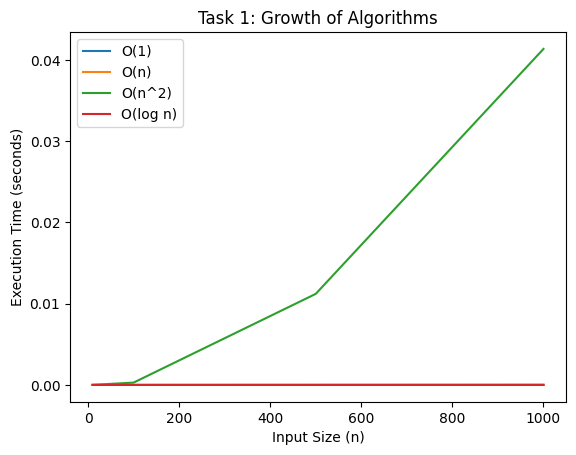

In [30]:
#Measure Execution Time & Plot
input_sizes = [10, 100, 500, 1000]
functions = [
    ("O(1)", constant_time),
    ("O(n)", linear_time),
    ("O(n^2)", quadratic_time),
    ("O(log n)", logarithmic_time)
]

plt.figure()

for label, func in functions:
    times = []
    for n in input_sizes:
        start = time.time()
        func(n)
        end = time.time()
        times.append(end - start)
    plt.plot(input_sizes, times, label=label)

plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Task 1: Growth of Algorithms")
plt.legend()
plt.show()


In [32]:
#Task 2--Best, Average, Worst Case Analysis

def linear_search(arr, key):
    for i in arr:
        if i == key:
            return True
    return False


def binary_search(arr, key):
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == key:
            return True
        elif arr[mid] < key:
            low = mid + 1
        else:
            high = mid - 1
    return False


In [33]:
#Time Measurement
sizes = [100, 500, 1000]
cases = ["Best", "Average", "Worst"]

linear_times = []
binary_times = []

for n in sizes:
    arr = sorted(random.sample(range(1, n*5), n))

    # Best case
    start = time.time()
    linear_search(arr, arr[0])
    linear_times.append(time.time() - start)

    start = time.time()
    binary_search(arr, arr[n//2])
    binary_times.append(time.time() - start)


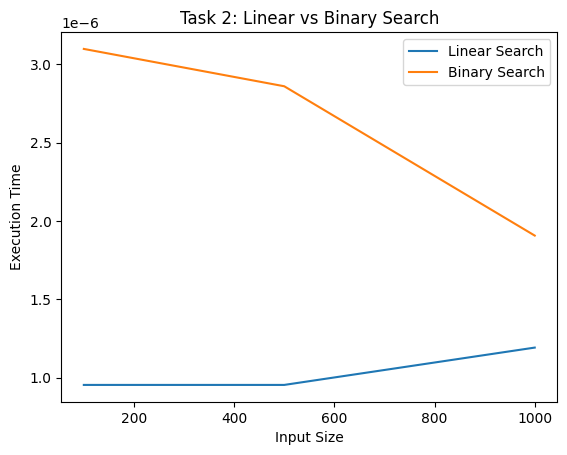

In [ ]:
#Plot Comparison
plt.plot(sizes, linear_times, label="Linear Search")
plt.plot(sizes, binary_times, label="Binary Search")
plt.xlabel("Input Size")
plt.ylabel("Execution Time")
plt.title("Task 2: Linear vs Binary Search")
plt.legend()
plt.show()


In [34]:
#Task 3--Recursion and Recurrence Validation
def factorial(n):
    if n == 0:
        return 1
    return n * factorial(n - 1)


In [35]:
#Fibonacci
fib_calls = 0
def fibonacci_recursive(n):
    global fib_calls
    fib_calls += 1
    if n <= 1:
        return n
    return fibonacci_recursive(n-1) + fibonacci_recursive(n-2)


In [36]:
#Fibonacci (Dynamic Programming)
fib_dp_calls = 0

@lru_cache(None)
def fibonacci_dp(n):
    global fib_dp_calls
    fib_dp_calls += 1
    if n <= 1:
        return n
    return fibonacci_dp(n-1) + fibonacci_dp(n-2)


In [37]:
#Comparison Table
n = 10

fib_calls = 0
start = time.time()
fibonacci_recursive(n)
t1 = time.time() - start

fib_dp_calls = 0
start = time.time()
fibonacci_dp(n)
t2 = time.time() - start

print("Naive Fibonacci: Calls =", fib_calls, " Time =", t1)
print("DP Fibonacci: Calls =", fib_dp_calls, " Time =", t2)


Naive Fibonacci: Calls = 177  Time = 6.127357482910156e-05
DP Fibonacci: Calls = 11  Time = 4.00543212890625e-05


In [38]:
# Task 4--Solving Recurrences through Code

#T(n) = T(n/2) + n

calls1 = 0
def recurrence1(n):
    global calls1
    calls1 += 1
    if n <= 1:
        return 1
    return recurrence1(n//2) + n


In [39]:
#T(n) = 2T(n/2) + n

calls2 = 0
def recurrence2(n):
    global calls2
    calls2 += 1
    if n <= 1:
        return 1
    return recurrence2(n//2) + recurrence2(n//2) + n


In [40]:
#Test & Observe

n = 1024

calls1 = 0
recurrence1(n)
print("T(n) = T(n/2) + n → Calls:", calls1)

calls2 = 0
recurrence2(n)
print("T(n) = 2T(n/2) + n → Calls:", calls2)


T(n) = T(n/2) + n → Calls: 11
T(n) = 2T(n/2) + n → Calls: 2047
